In [ ]:
import os
import shutil

backup_dir = "ll_calibration_backup"
os.makedirs(backup_dir, exist_ok=True)

DEVICE = cuda
BACKUP = /content/ll_calibration_backup
Saved precomputed result for d=5 -> geometry_meta_d5.json
Saved precomputed result for d=10 -> geometry_meta_d10.json
Model loaded.


100%|██████████| 170M/170M [00:05<00:00, 31.1MB/s]


analysis subset size = 1024

Computing for d = 15
eig 1/15: lambda=4.705271e+00
eig 2/15: lambda=3.094097e+00
eig 3/15: lambda=2.050543e+00
eig 4/15: lambda=2.244546e+00
eig 5/15: lambda=1.641454e+00
eig 6/15: lambda=1.730298e+00
eig 7/15: lambda=1.405184e+00
eig 8/15: lambda=1.444624e+00
eig 9/15: lambda=1.263123e+00
eig 10/15: lambda=1.120958e+00
eig 11/15: lambda=1.051880e+00
eig 12/15: lambda=9.147266e-01
eig 13/15: lambda=9.278160e-01
eig 14/15: lambda=8.070391e-01
eig 15/15: lambda=7.129068e-01
dir 1/20 done
dir 2/20 done
dir 3/20 done
dir 4/20 done
dir 5/20 done
dir 6/20 done
dir 7/20 done
dir 8/20 done
dir 9/20 done
dir 10/20 done
dir 11/20 done
dir 12/20 done
dir 13/20 done
dir 14/20 done
dir 15/20 done
dir 16/20 done
dir 17/20 done
dir 18/20 done
dir 19/20 done
dir 20/20 done
[SAVED] d=15
{
  "d": 15,
  "psi": 0.1,
  "epsilon": 0.05,
  "lambda_min": 0.7129068374633789,
  "lambda_max": 4.705271244049072,
  "lambda_mean": 1.6742979288101196,
  "L_hat_strict_max": 560.1697564125

,d,psi,epsilon,lambda_min,lambda_max,lambda_mean,L_hat_strict_max,L_hat_robust_quantile,L_hat_median,L_hat_used,R_psi,chi2_quantile,sqrt_chi2_quantile,sigma_star
0,5,0.1,0.05,1.641453,4.705271,2.747183,1129.308462,1014.607829,392.085388,1129.308462,0.000436,11.070498,3.327236,0.000131
1,10,0.1,0.05,1.096511,4.695068,2.066509,751.997158,721.682602,350.691598,751.997158,0.000437,18.307038,4.278672,0.000102
2,15,0.1,0.05,0.712907,4.705271,1.674298,560.169756,518.293807,249.704596,560.169756,0.000382,24.995790,4.999579,0.000076
3,20,0.1,0.05,0.565607,4.705267,1.415971,696.908712,626.985312,324.295200,696.908712,0.000243,31.410433,5.604501,0.000043


ValueError: 
\sigma^\*(d)
       ^
ParseSyntaxException: Expected {accent | symbol | function | operatorname | group | frac | dfrac | binom | genfrac | overset | underset | sqrt | overline | text | boldsymbol | substack}, found '\'  (at char 7), (line:1, col:8)

<Figure size 700x480 with 1 Axes>

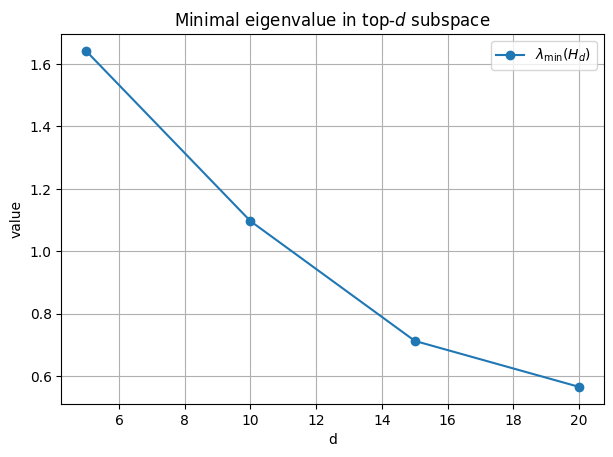

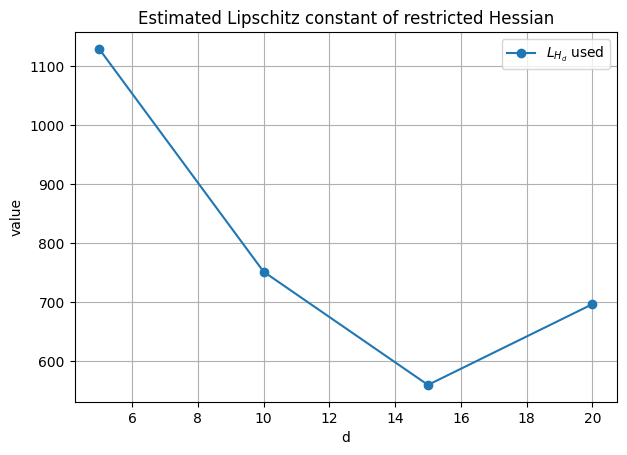

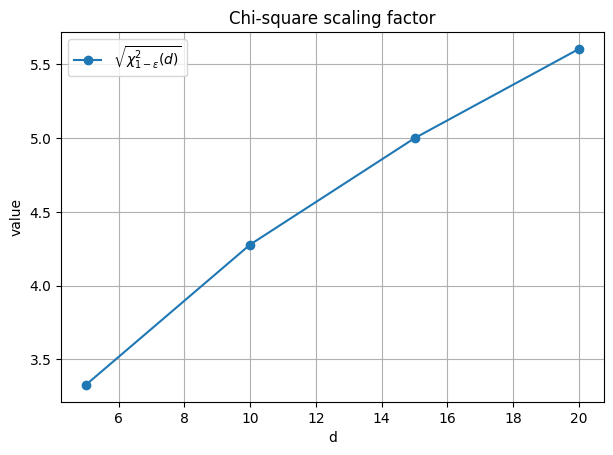

ValueError: 
\sigma^\*(d) / \sigma^\*(10)
       ^
ParseSyntaxException: Expected {accent | symbol | function | operatorname | group | frac | dfrac | binom | genfrac | overset | underset | sqrt | overline | text | boldsymbol | substack}, found '\'  (at char 7), (line:1, col:8)

<Figure size 700x480 with 1 Axes>

,d,psi,epsilon,lambda_min,lambda_max,lambda_mean,L_hat_strict_max,L_hat_robust_quantile,L_hat_median,L_hat_used,R_psi,chi2_quantile,sqrt_chi2_quantile,sigma_star,sigma_star_over_sigma_star_d10
0,5,0.1,0.05,1.641453,4.705271,2.747183,1129.308462,1014.607829,392.085388,1129.308462,0.000436,11.070498,3.327236,0.000131,1.281871
1,10,0.1,0.05,1.096511,4.695068,2.066509,751.997158,721.682602,350.691598,751.997158,0.000437,18.307038,4.278672,0.000102,1.000000
2,15,0.1,0.05,0.712907,4.705271,1.674298,560.169756,518.293807,249.704596,560.169756,0.000382,24.995790,4.999579,0.000076,0.746950
3,20,0.1,0.05,0.565607,4.705267,1.415971,696.908712,626.985312,324.295200,696.908712,0.000243,31.410433,5.604501,0.000043,0.424926



Done.
Saved results to: /content/ll_calibration_backup/sigma_star_vs_d
Master CSV: /content/ll_calibration_backup/sigma_star_vs_d/sigma_star_vs_d.csv


In [ ]:
# ============================================================
# CONTINUE sigma*(d): use existing d=5,10 and compute d=15,20
# Работает в Colab, где загружены только файлы результатов обучения
# ============================================================

import os
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

# -----------------------------
# 0. SETTINGS
# -----------------------------
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_WORKERS = 2

# все d, которые хотим иметь на выходе
D_GRID = [5, 10, 15, 20]

# считать нужно только эти d
D_TO_COMPUTE = [15, 20]

POWER_ITERS = 12
POWER_TOL = 1e-5

# как обсуждали: не 100, а 20 направлений
LH_NUM_DIRS = 20
LH_T_VALUES = (1e-4, 5e-4)
LH_QUANTILE = 0.95

PSI = 0.10
EPSILON = 0.05
EVAL_BATCH_SIZE = 256

# уже готовые результаты
PRECOMPUTED_RESULTS = {
    5: {
        "d": 5,
        "psi": 0.1,
        "epsilon": 0.05,
        "lambda_min": 1.6414532661437988,
        "lambda_max": 4.705270767211914,
        "lambda_mean": 2.747182607650757,
        "L_hat_strict_max": 1129.3084621429443,
        "L_hat_robust_quantile": 1014.6078288555143,
        "L_hat_median": 392.08538830280304,
        "L_hat_used": 1129.3084621429443,
        "R_psi": 0.0004360509075693163,
        "chi2_quantile": 11.070497693516351,
        "sqrt_chi2_quantile": 3.327235743604043,
        "sigma_star": 0.000131055008172336
    },
    10: {
        "d": 10,
        "psi": 0.1,
        "epsilon": 0.05,
        "lambda_min": 1.0965113639831543,
        "lambda_max": 4.695068359375,
        "lambda_mean": 2.066509485244751,
        "L_hat_strict_max": 751.9971579313278,
        "L_hat_robust_quantile": 721.6826021671295,
        "L_hat_median": 350.6915979087353,
        "L_hat_used": 751.9971579313278,
        "R_psi": 0.0004374396973784657,
        "chi2_quantile": 18.307038053275146,
        "sqrt_chi2_quantile": 4.278672463892877,
        "sigma_star": 0.00010223724790106243
    }
}

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print("DEVICE =", DEVICE)


# -----------------------------
# 1. FIND BACKUP DIRECTORY
# -----------------------------
def find_backup_dir():
    candidates = [
        Path("./ll_calibration_backup"),
        Path("/content/ll_calibration_backup"),
        Path("/mnt/data/ll_calibration_backup"),
        Path("./drive/MyDrive/ll_calibration_backup"),
        Path("/content/drive/MyDrive/ll_calibration_backup"),
    ]
    for p in candidates:
        if p.exists():
            return p.resolve()

    roots = [Path("."), Path("/content"), Path("/mnt/data")]
    for root in roots:
        if root.exists():
            for p in root.rglob("ll_calibration_backup"):
                if p.is_dir():
                    return p.resolve()

    raise FileNotFoundError("Не найдена папка ll_calibration_backup")

BACKUP = find_backup_dir()
print("BACKUP =", BACKUP)

required_files = ["w_star.pt", "splits.json"]
for fname in required_files:
    fpath = BACKUP / fname
    if not fpath.exists():
        raise FileNotFoundError(f"Не найден обязательный файл: {fpath}")

OUT_D = BACKUP / "sigma_star_vs_d"
OUT_D.mkdir(parents=True, exist_ok=True)
CSV_PATH = OUT_D / "sigma_star_vs_d.csv"


# -----------------------------
# 2. SAVE PRECOMPUTED d=5,10
# -----------------------------
for d, row in PRECOMPUTED_RESULTS.items():
    path = OUT_D / f"geometry_meta_d{d}.json"
    if not path.exists():
        with open(path, "w") as f:
            json.dump(row, f, indent=2)
        print(f"Saved precomputed result for d={d} -> {path.name}")
    else:
        print(f"Already exists: {path.name}")


# -----------------------------
# 3. MODEL + HELPERS
# -----------------------------
def build_eval_transform():
    return transforms.Compose([transforms.ToTensor()])

def make_cifar_resnet18(num_classes=10):
    model = models.resnet18(weights=None, num_classes=num_classes)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model

def trainable_params(model):
    return [p for p in model.parameters() if p.requires_grad]

def get_param_vector(model):
    return parameters_to_vector(trainable_params(model)).detach().clone()

@torch.no_grad()
def set_param_vector(model, theta):
    vector_to_parameters(theta, trainable_params(model))

def normalize(v, eps=1e-12):
    return v / (torch.linalg.vector_norm(v) + eps)

def orthogonalize(v, basis):
    if len(basis) == 0:
        return v
    B = torch.stack(basis, dim=1)
    coeffs = B.T @ v
    return v - B @ coeffs

def subset_loss(model, loader, device, create_graph=False):
    model.eval()
    total_loss = None
    total_n = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        batch_loss = F.cross_entropy(logits, y, reduction="sum")
        total_loss = batch_loss if total_loss is None else total_loss + batch_loss
        total_n += y.size(0)

    return total_loss / total_n

def hvp(model, loader, vec, device):
    params = trainable_params(model)
    loss = subset_loss(model, loader, device, create_graph=True)
    grads = torch.autograd.grad(loss, params, create_graph=True, retain_graph=True)
    flat_grads = torch.cat([g.reshape(-1) for g in grads])

    dot = torch.dot(flat_grads, vec)
    hv = torch.autograd.grad(dot, params, retain_graph=False)

    flat_hv = []
    for p, g in zip(params, hv):
        if g is None:
            flat_hv.append(torch.zeros_like(p).reshape(-1))
        else:
            flat_hv.append(g.reshape(-1))
    return torch.cat(flat_hv).detach()


# -----------------------------
# 4. LOAD MODEL
# -----------------------------
model = make_cifar_resnet18().to(DEVICE)
ckpt = torch.load(BACKUP / "w_star.pt", map_location=DEVICE)

if "model_state" in ckpt:
    model.load_state_dict(ckpt["model_state"])
else:
    model.load_state_dict(ckpt)

model.eval()
base_theta = get_param_vector(model).to(DEVICE)
print("Model loaded.")


# -----------------------------
# 5. RESTORE ANALYSIS SUBSET
# -----------------------------
with open(BACKUP / "splits.json", "r") as f:
    splits = json.load(f)

analysis_idx = splits["analysis_idx"]

data_root_candidates = [
    Path("/content/data"),
    Path("./data"),
    Path("/mnt/data/data"),
]
data_root = None
for p in data_root_candidates:
    try:
        p.mkdir(parents=True, exist_ok=True)
        data_root = p
        break
    except Exception:
        pass

if data_root is None:
    data_root = Path("./data")
    data_root.mkdir(parents=True, exist_ok=True)

eval_tf = build_eval_transform()
full_train_eval = datasets.CIFAR10(root=str(data_root), train=True, download=True, transform=eval_tf)
analysis_ds = Subset(full_train_eval, analysis_idx)
analysis_loader = DataLoader(
    analysis_ds,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("analysis subset size =", len(analysis_ds))


# -----------------------------
# 6. TOP EIGENSPACE
# -----------------------------
def top_eigenspace(model, loader, d, device, n_iters=12, tol=1e-5):
    theta0 = get_param_vector(model).to(device)
    p = theta0.numel()

    eigvals = []
    eigvecs = []

    for k in range(d):
        v = torch.randn(p, device=device)
        v = orthogonalize(v, eigvecs)
        v = normalize(v)

        prev_lambda = None
        for _ in range(n_iters):
            Hv = hvp(model, loader, v, device)
            Hv = orthogonalize(Hv, eigvecs)

            lam = torch.dot(v, Hv).item()
            Hv_norm = torch.linalg.vector_norm(Hv).item()
            if Hv_norm < 1e-12:
                raise RuntimeError(f"degenerate direction at k={k}")

            v = Hv / Hv_norm

            if prev_lambda is not None:
                rel_change = abs(lam - prev_lambda) / max(1.0, abs(lam))
                if rel_change < tol:
                    break
            prev_lambda = lam

        Hv = hvp(model, loader, v, device)
        lam = torch.dot(v, Hv).item()
        eigvals.append(lam)
        eigvecs.append(v.detach())
        print(f"eig {k+1}/{d}: lambda={lam:.6e}")

    lambdas = torch.tensor(eigvals, device=device)
    U = torch.stack(eigvecs, dim=1)
    return lambdas, U


# -----------------------------
# 7. RESTRICTED HESSIAN + LH
# -----------------------------
def restricted_hessian_matrix(model, loader, U, base_theta, step_subspace, device):
    d = U.shape[1]
    theta = base_theta + U @ step_subspace
    set_param_vector(model, theta)

    cols = []
    for j in range(d):
        uj = U[:, j]
        Huj = hvp(model, loader, uj, device)
        col = U.T @ Huj
        cols.append(col)

    H_d = torch.stack(cols, dim=1)
    set_param_vector(model, base_theta)
    return H_d

def estimate_local_hessian_lipschitz(model, loader, U, base_theta, device,
                                     t_values, num_dirs, quantile=0.95):
    d = U.shape[1]
    H0 = restricted_hessian_matrix(
        model, loader, U, base_theta,
        step_subspace=torch.zeros(d, device=device),
        device=device
    )

    estimates = []

    for j in range(num_dirs):
        v = normalize(torch.randn(d, device=device))
        for t in t_values:
            Ht = restricted_hessian_matrix(
                model, loader, U, base_theta,
                step_subspace=t * v,
                device=device
            )
            diff = Ht - H0
            spec = torch.linalg.svdvals(diff)[0].item()
            estimates.append(spec / t)
        print(f"dir {j+1}/{num_dirs} done")

    arr = np.asarray(estimates)
    return {
        "strict_max": float(arr.max()),
        "robust_quantile": float(np.quantile(arr, quantile)),
        "median": float(np.median(arr)),
        "all_values": arr.tolist(),
    }


# -----------------------------
# 8. CHECKPOINT HELPERS
# -----------------------------
def per_d_json_path(d):
    return OUT_D / f"geometry_meta_d{d}.json"

def per_d_eig_path(d):
    return OUT_D / f"eigenspace_d{d}.pt"

def refresh_master_csv():
    rows = []
    for d in D_GRID:
        path = per_d_json_path(d)
        if path.exists():
            with open(path, "r") as f:
                rows.append(json.load(f))
    if rows:
        df = pd.DataFrame(rows).sort_values("d").reset_index(drop=True)
        df.to_csv(CSV_PATH, index=False)
        return df
    return pd.DataFrame()

def compute_for_d(d):
    print("\n" + "=" * 60)
    print(f"Computing for d = {d}")
    print("=" * 60)

    lambdas_d, U_d = top_eigenspace(
        model=model,
        loader=analysis_loader,
        d=d,
        device=DEVICE,
        n_iters=POWER_ITERS,
        tol=POWER_TOL,
    )

    L_stats_d = estimate_local_hessian_lipschitz(
        model=model,
        loader=analysis_loader,
        U=U_d,
        base_theta=base_theta,
        device=DEVICE,
        t_values=LH_T_VALUES,
        num_dirs=LH_NUM_DIRS,
        quantile=LH_QUANTILE,
    )

    L_hat_d = float(L_stats_d["strict_max"])

    lambda_min_d = float(torch.min(lambdas_d).item())
    lambda_max_d = float(torch.max(lambdas_d).item())
    lambda_mean_d = float(torch.mean(lambdas_d).item())

    R_psi_d = 3.0 * PSI * lambda_min_d / L_hat_d
    chi_quant_d = float(chi2.ppf(1.0 - EPSILON, d))
    sigma_star_d = R_psi_d / math.sqrt(chi_quant_d)

    row = {
        "d": int(d),
        "psi": float(PSI),
        "epsilon": float(EPSILON),
        "lambda_min": float(lambda_min_d),
        "lambda_max": float(lambda_max_d),
        "lambda_mean": float(lambda_mean_d),
        "L_hat_strict_max": float(L_stats_d["strict_max"]),
        "L_hat_robust_quantile": float(L_stats_d["robust_quantile"]),
        "L_hat_median": float(L_stats_d["median"]),
        "L_hat_used": float(L_hat_d),
        "R_psi": float(R_psi_d),
        "chi2_quantile": float(chi_quant_d),
        "sqrt_chi2_quantile": float(math.sqrt(chi_quant_d)),
        "sigma_star": float(sigma_star_d),
    }

    torch.save(
        {
            "lambdas": lambdas_d.detach().cpu(),
            "U": U_d.detach().cpu(),
        },
        per_d_eig_path(d)
    )

    with open(per_d_json_path(d), "w") as f:
        json.dump(row, f, indent=2)

    df = refresh_master_csv()

    print(f"[SAVED] d={d}")
    print(json.dumps(row, indent=2))
    return row, df


# -----------------------------
# 9. COMPUTE ONLY REMAINING d
# -----------------------------
for d in D_TO_COMPUTE:
    if per_d_json_path(d).exists():
        print(f"[SKIP] d={d} already exists")
        continue
    compute_for_d(d)

sigma_d_df = refresh_master_csv()

if sigma_d_df.empty:
    raise RuntimeError("No results were found.")

print("\nFinal table:")
display(sigma_d_df)


# -----------------------------
# 10. PLOTS
# -----------------------------
plt.figure(figsize=(7, 4.8))
plt.plot(sigma_d_df["d"], sigma_d_df["sigma_star"], marker="o", linewidth=2)
plt.xlabel("d")
plt.ylabel(r"$\sigma^\*(d)$")
plt.title(r"Dependence of $\sigma^\*$ on subspace dimension $d$")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4.8))
plt.plot(sigma_d_df["d"], sigma_d_df["lambda_min"], marker="o", label=r"$\lambda_{\min}(H_d)$")
plt.xlabel("d")
plt.ylabel("value")
plt.title(r"Minimal eigenvalue in top-$d$ subspace")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7, 4.8))
plt.plot(sigma_d_df["d"], sigma_d_df["L_hat_used"], marker="o", label=r"$L_{H_d}$ used")
plt.xlabel("d")
plt.ylabel("value")
plt.title(r"Estimated Lipschitz constant of restricted Hessian")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7, 4.8))
plt.plot(sigma_d_df["d"], sigma_d_df["sqrt_chi2_quantile"], marker="o", label=r"$\sqrt{\chi^2_{1-\epsilon}(d)}$")
plt.xlabel("d")
plt.ylabel("value")
plt.title(r"Chi-square scaling factor")
plt.grid(True)
plt.legend()
plt.show()

if 10 in sigma_d_df["d"].values:
    sigma_ref = float(sigma_d_df.loc[sigma_d_df["d"] == 10, "sigma_star"].iloc[0])
    sigma_d_df["sigma_star_over_sigma_star_d10"] = sigma_d_df["sigma_star"] / sigma_ref

    plt.figure(figsize=(7, 4.8))
    plt.plot(
        sigma_d_df["d"],
        sigma_d_df["sigma_star_over_sigma_star_d10"],
        marker="o",
        linewidth=2
    )
    plt.axhline(1.0, linestyle="--")
    plt.xlabel("d")
    plt.ylabel(r"$\sigma^\*(d) / \sigma^\*(10)$")
    plt.title(r"Relative change of $\sigma^\*$ with $d$")
    plt.grid(True)
    plt.show()

display(sigma_d_df)

print("\nDone.")
print("Saved results to:", OUT_D)
print("Master CSV:", CSV_PATH)

SIGMA_DIR = /content/ll_calibration_backup/sigma_star_vs_d


,d,sigma_star,lambda_min,L_hat_used,sqrt_chi2_quantile
0,5,0.000131,1.641453,1129.308462,3.327236
1,10,0.000102,1.096511,751.997158,4.278672
2,15,0.000076,0.712907,560.169756,4.999579
3,20,0.000043,0.565607,696.908712,5.604501


ValueError: 
\sigma^\*(d)
       ^
ParseSyntaxException: Expected {accent | symbol | function | operatorname | group | frac | dfrac | binom | genfrac | overset | underset | sqrt | overline | text | boldsymbol | substack}, found '\'  (at char 7), (line:1, col:8)

<Figure size 700x480 with 1 Axes>

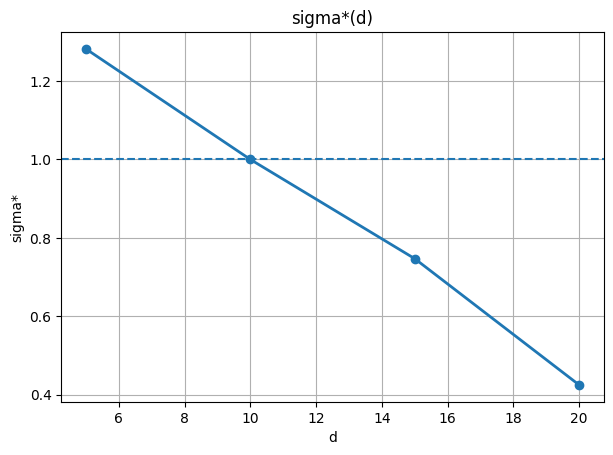

In [ ]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Найти папку с результатами sigma_star_vs_d
# --------------------------------------------------
def find_sigma_dir():
    candidates = [
        Path("./ll_calibration_backup/sigma_star_vs_d"),
        Path("/content/ll_calibration_backup/sigma_star_vs_d"),
        Path("/mnt/data/ll_calibration_backup/sigma_star_vs_d"),
        Path("./sigma_star_vs_d"),
    ]
    for p in candidates:
        if p.exists():
            return p.resolve()
    raise FileNotFoundError("Не найдена папка sigma_star_vs_d")

SIGMA_DIR = find_sigma_dir()
print("SIGMA_DIR =", SIGMA_DIR)

# --------------------------------------------------
# 2. Считать все geometry_meta_d*.json
# --------------------------------------------------
rows = []
for path in sorted(SIGMA_DIR.glob("geometry_meta_d*.json")):
    with open(path, "r") as f:
        rows.append(json.load(f))

if not rows:
    raise RuntimeError("Не найдено ни одного geometry_meta_d*.json")

df = pd.DataFrame(rows).sort_values("d").reset_index(drop=True)
display(df[["d", "sigma_star", "lambda_min", "L_hat_used", "sqrt_chi2_quantile"]])

# --------------------------------------------------
# 3. Построить sigma*(d)
# --------------------------------------------------
plt.figure(figsize=(7, 4.8))
plt.plot(df["d"], df["sigma_star"], marker="o", linewidth=2)
plt.xlabel("d")
plt.ylabel(r"$\sigma^\*(d)$")
plt.title(r"Dependence of $\sigma^\*$ on subspace dimension $d$")
plt.grid(True)
plt.show()

# --------------------------------------------------
# 4. Дополнительно: относительное изменение к d=10
# --------------------------------------------------
if 10 in df["d"].values:
    sigma_ref = float(df.loc[df["d"] == 10, "sigma_star"].iloc[0])
    df["sigma_star_over_sigma_star_d10"] = df["sigma_star"] / sigma_ref

    plt.figure(figsize=(7, 4.8))
    plt.plot(df["d"], df["sigma_star_over_sigma_star_d10"], marker="o", linewidth=2)
    plt.axhline(1.0, linestyle="--")
    plt.xlabel("d")
    plt.ylabel("sigma*")
    plt.title("sigma*(d)")
    plt.grid(True)
    plt.show()

,d,sigma_star,lambda_min,L_hat_used,sqrt_chi2_quantile
0,5,0.000131,1.641453,1129.308462,3.327236
1,10,0.000102,1.096511,751.997158,4.278672
2,15,0.000076,0.712907,560.169756,4.999579
3,20,0.000043,0.565607,696.908712,5.604501


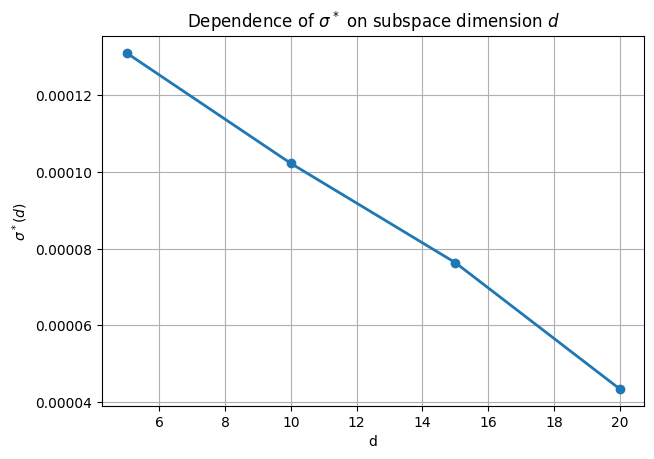

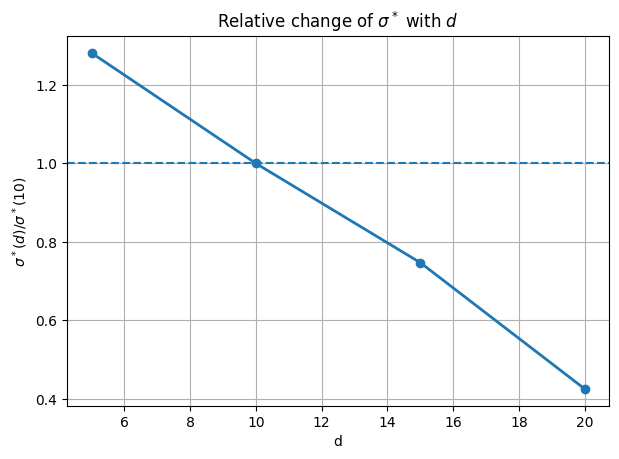

In [ ]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

sigma_dir = Path("/content/ll_calibration_backup/sigma_star_vs_d")

rows = []
for path in sorted(sigma_dir.glob("geometry_meta_d*.json")):
    with open(path, "r") as f:
        rows.append(json.load(f))

df = pd.DataFrame(rows).sort_values("d").reset_index(drop=True)
display(df[["d", "sigma_star", "lambda_min", "L_hat_used", "sqrt_chi2_quantile"]])

plt.figure(figsize=(7, 4.8))
plt.plot(df["d"], df["sigma_star"], marker="o", linewidth=2)
plt.xlabel("d")
plt.ylabel(r"$\sigma^*(d)$")
plt.title(r"Dependence of $\sigma^*$ on subspace dimension $d$")
plt.grid(True)
plt.show()

if 10 in df["d"].values:
    sigma_ref = float(df.loc[df["d"] == 10, "sigma_star"].iloc[0])
    df["sigma_star_over_sigma_star_d10"] = df["sigma_star"] / sigma_ref

    plt.figure(figsize=(7, 4.8))
    plt.plot(df["d"], df["sigma_star_over_sigma_star_d10"], marker="o", linewidth=2)
    plt.axhline(1.0, linestyle="--")
    plt.xlabel("d")
    plt.ylabel(r"$\sigma^*(d)/\sigma^*(10)$")
    plt.title(r"Relative change of $\sigma^*$ with $d$")
    plt.grid(True)
    plt.show()

Уже посчитанные d: [5, 10, 15, 20]


,d,sigma_star,lambda_min,L_hat_used,sqrt_chi2_quantile
0,5,0.000131,1.641453,1129.308462,3.327236
1,10,0.000102,1.096511,751.997158,4.278672
2,15,0.000076,0.712907,560.169756,4.999579
3,20,0.000043,0.565607,696.908712,5.604501



=== Computing for d = 25 ===
eig 1/25: lambda=4.703972e+00
eig 2/25: lambda=3.094267e+00
eig 3/25: lambda=2.063704e+00
eig 4/25: lambda=2.262128e+00
eig 5/25: lambda=1.660769e+00
eig 6/25: lambda=1.600253e+00
eig 7/25: lambda=1.413791e+00
eig 8/25: lambda=1.498946e+00
eig 9/25: lambda=1.274893e+00
eig 10/25: lambda=1.123179e+00
eig 11/25: lambda=1.071884e+00
eig 12/25: lambda=8.948978e-01
eig 13/25: lambda=9.206004e-01
eig 14/25: lambda=8.197050e-01
eig 15/25: lambda=7.039220e-01
eig 16/25: lambda=6.729218e-01
eig 17/25: lambda=6.453629e-01
eig 18/25: lambda=6.715544e-01
eig 19/25: lambda=6.591512e-01
eig 20/25: lambda=5.614984e-01
eig 21/25: lambda=5.658476e-01
eig 22/25: lambda=5.193915e-01
eig 23/25: lambda=5.144506e-01
eig 24/25: lambda=5.094594e-01
eig 25/25: lambda=4.510254e-01
dir 1/20 done
dir 2/20 done
dir 3/20 done
dir 4/20 done
dir 5/20 done
dir 6/20 done
dir 7/20 done
dir 8/20 done
dir 9/20 done
dir 10/20 done
dir 11/20 done
dir 12/20 done
dir 13/20 done
dir 14/20 done
dir

,d,sigma_star,lambda_min,L_hat_used,sqrt_chi2_quantile
0,5,0.000131,1.641453,1129.308462,3.327236
1,10,0.000102,1.096511,751.997158,4.278672
2,15,0.000076,0.712907,560.169756,4.999579
3,20,0.000043,0.565607,696.908712,5.604501
4,25,0.000032,0.451025,688.413829,6.136162


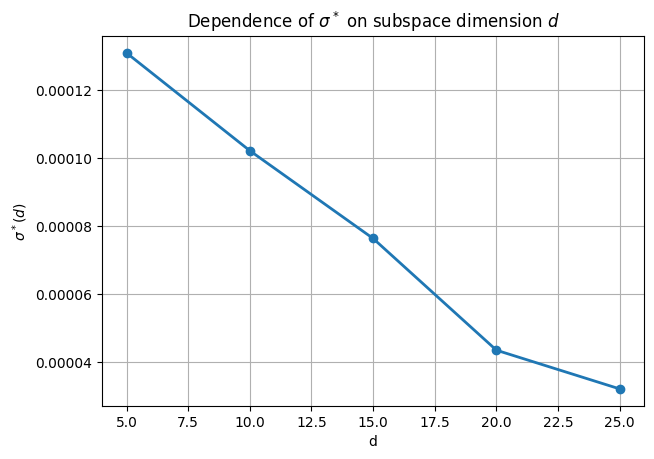

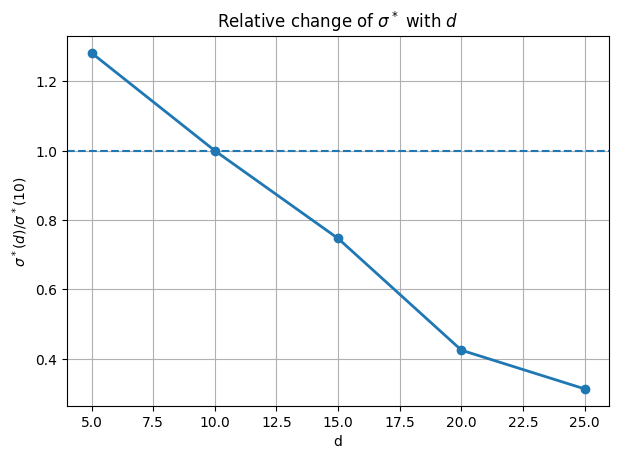

In [ ]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Папка с уже посчитанными результатами
# --------------------------------------------------
sigma_dir = Path("/content/ll_calibration_backup/sigma_star_vs_d")

# --------------------------------------------------
# 2. Считать все готовые geometry_meta_d*.json
# --------------------------------------------------
rows = []
for path in sorted(sigma_dir.glob("geometry_meta_d*.json")):
    with open(path, "r") as f:
        rows.append(json.load(f))

df = pd.DataFrame(rows).sort_values("d").reset_index(drop=True)
print("Уже посчитанные d:", df["d"].tolist())
display(df[["d", "sigma_star", "lambda_min", "L_hat_used", "sqrt_chi2_quantile"]])

# --------------------------------------------------
# 3. Достать последний посчитанный d и посчитать d=25
# --------------------------------------------------
if 25 in df["d"].values:
    print("d = 25 уже посчитан, пересчёт не нужен.")
else:
    d = 25

    print(f"\n=== Computing for d = {d} ===")

    lambdas_d, U_d = top_eigenspace(
        model=model,
        loader=analysis_loader,
        d=d,
        device=DEVICE,
        n_iters=POWER_ITERS,
        tol=POWER_TOL,
    )

    L_stats_d = estimate_local_hessian_lipschitz(
        model=model,
        loader=analysis_loader,
        U=U_d,
        base_theta=base_theta,
        device=DEVICE,
        t_values=LH_T_VALUES,
        num_dirs=LH_NUM_DIRS,
        quantile=LH_QUANTILE,
    )

    L_hat_d = float(L_stats_d["strict_max"])
    lambda_min_d = float(torch.min(lambdas_d).item())
    lambda_max_d = float(torch.max(lambdas_d).item())
    lambda_mean_d = float(torch.mean(lambdas_d).item())

    R_psi_d = 3.0 * PSI * lambda_min_d / L_hat_d
    chi_quant_d = float(chi2.ppf(1.0 - EPSILON, d))
    sigma_star_d = R_psi_d / math.sqrt(chi_quant_d)

    row = {
        "d": int(d),
        "psi": float(PSI),
        "epsilon": float(EPSILON),
        "lambda_min": float(lambda_min_d),
        "lambda_max": float(lambda_max_d),
        "lambda_mean": float(lambda_mean_d),
        "L_hat_strict_max": float(L_stats_d["strict_max"]),
        "L_hat_robust_quantile": float(L_stats_d["robust_quantile"]),
        "L_hat_median": float(L_stats_d["median"]),
        "L_hat_used": float(L_hat_d),
        "R_psi": float(R_psi_d),
        "chi2_quantile": float(chi_quant_d),
        "sqrt_chi2_quantile": float(math.sqrt(chi_quant_d)),
        "sigma_star": float(sigma_star_d),
    }

    # сохранить результаты для d=25
    torch.save(
        {
            "lambdas": lambdas_d.detach().cpu(),
            "U": U_d.detach().cpu(),
        },
        sigma_dir / "eigenspace_d25.pt"
    )

    with open(sigma_dir / "geometry_meta_d25.json", "w") as f:
        json.dump(row, f, indent=2)

    print("Saved d=25")
    print(json.dumps(row, indent=2))

# --------------------------------------------------
# 4. Перечитать все результаты и построить новый график
# --------------------------------------------------
rows = []
for path in sorted(sigma_dir.glob("geometry_meta_d*.json")):
    with open(path, "r") as f:
        rows.append(json.load(f))

df = pd.DataFrame(rows).sort_values("d").reset_index(drop=True)

# обновить master csv
df.to_csv(sigma_dir / "sigma_star_vs_d.csv", index=False)

display(df[["d", "sigma_star", "lambda_min", "L_hat_used", "sqrt_chi2_quantile"]])

plt.figure(figsize=(7, 4.8))
plt.plot(df["d"], df["sigma_star"], marker="o", linewidth=2)
plt.xlabel("d")
plt.ylabel(r"$\sigma^*(d)$")
plt.title(r"Dependence of $\sigma^*$ on subspace dimension $d$")
plt.grid(True)
plt.show()

if 10 in df["d"].values:
    sigma_ref = float(df.loc[df["d"] == 10, "sigma_star"].iloc[0])
    df["sigma_star_over_sigma_star_d10"] = df["sigma_star"] / sigma_ref

    plt.figure(figsize=(7, 4.8))
    plt.plot(df["d"], df["sigma_star_over_sigma_star_d10"], marker="o", linewidth=2)
    plt.axhline(1.0, linestyle="--")
    plt.xlabel("d")
    plt.ylabel(r"$\sigma^*(d)/\sigma^*(10)$")
    plt.title(r"Relative change of $\sigma^*$ with $d$")
    plt.grid(True)
    plt.show()